In [9]:
import matplotlib.pyplot as plt
import torch


def tensor_to_numpy_gray(t):
    # t: [1, H, W], float32 [0, 1]
    return t.squeeze(0).detach().cpu().numpy()


def draw_superpoint_keypoints(ax, image, pts, title=""):
    """
    image: [H, W] numpy grayscale
    pts: [3, N] from MagicLeap SuperPointFrontend.run()
         row 0 = x, row 1 = y, row 2 = confidence
    """
    ax.imshow(image, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

    if pts is not None and pts.shape[1] > 0:
        xs = pts[0, :]
        ys = pts[1, :]
        ax.scatter(xs, ys, s=6, facecolors="none", edgecolors="r", linewidths=0.6)


def visualize_first_n_superpoint(superpoint, dataloader, n_items=4):
    batch = next(iter(dataloader))

    fixed = batch["fixed"][:n_items]      # [N, 1, H, W]
    moving = batch["moving"][:n_items]    # [N, 1, H, W]

    fig, axes = plt.subplots(n_items, 2, figsize=(10, 4 * n_items))

    if n_items == 1:
        axes = axes[None, :]

    for i in range(n_items):
        fixed_img = tensor_to_numpy_gray(fixed[i])
        moving_img = tensor_to_numpy_gray(moving[i])

        fixed_pts, fixed_desc, fixed_heatmap = superpoint.run(fixed_img)
        moving_pts, moving_desc, moving_heatmap = superpoint.run(moving_img)

        draw_superpoint_keypoints(
            axes[i, 0],
            fixed_img,
            fixed_pts,
            title=f"Fixed {i} | {fixed_pts.shape[1]} keypoints",
        )

        draw_superpoint_keypoints(
            axes[i, 1],
            moving_img,
            moving_pts,
            title=f"Moving {i} | {moving_pts.shape[1]} keypoints",
        )

    plt.tight_layout()
    plt.show()

In [10]:
import sys
from torch.utils.data import DataLoader
sys.path.append("..")
from core.dataset import QuadtreeWSIPairDataset
import conf

ANNOTATION_PATH = conf.ANNOTATION_PATH
CNN_INPUT_HEIGHT = conf.CNN_INPUT_HEIGHT
CNN_INPUT_WIDTH = conf.CNN_INPUT_WIDTH


dataset = QuadtreeWSIPairDataset(
    annotation_path=ANNOTATION_PATH,
    input_height=CNN_INPUT_HEIGHT,
    input_width=CNN_INPUT_WIDTH
)

loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

print("dataset length:", len(dataset))


dataset length: 10920


In [ ]:
import sys
sys.path.append("..")
from external.SuperPointPretrainedNetwork import SuperPointFrontend


device = "cuda" if torch.cuda.is_available() else "cpu"

superpoint = SuperPointFrontend(
    weights_path="superpoint_v1.pth",
    nms_dist=4,
    conf_thresh=0.015,
    nn_thresh=0.7,
    cuda=(device == "cuda"),
)


FileNotFoundError: [Errno 2] No such file or directory: 'superpoint_v1.pth'

/Users/alexanderhallmann/Desktop/medical-image-registration/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/alexanderhallmann/Desktop/medical-image-registration/pretraining_compare_detectors/SuperPointPretrainedNetwork.py:281: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  desc = torch.nn.functional.grid_sample(coarse_desc, samp_pts)


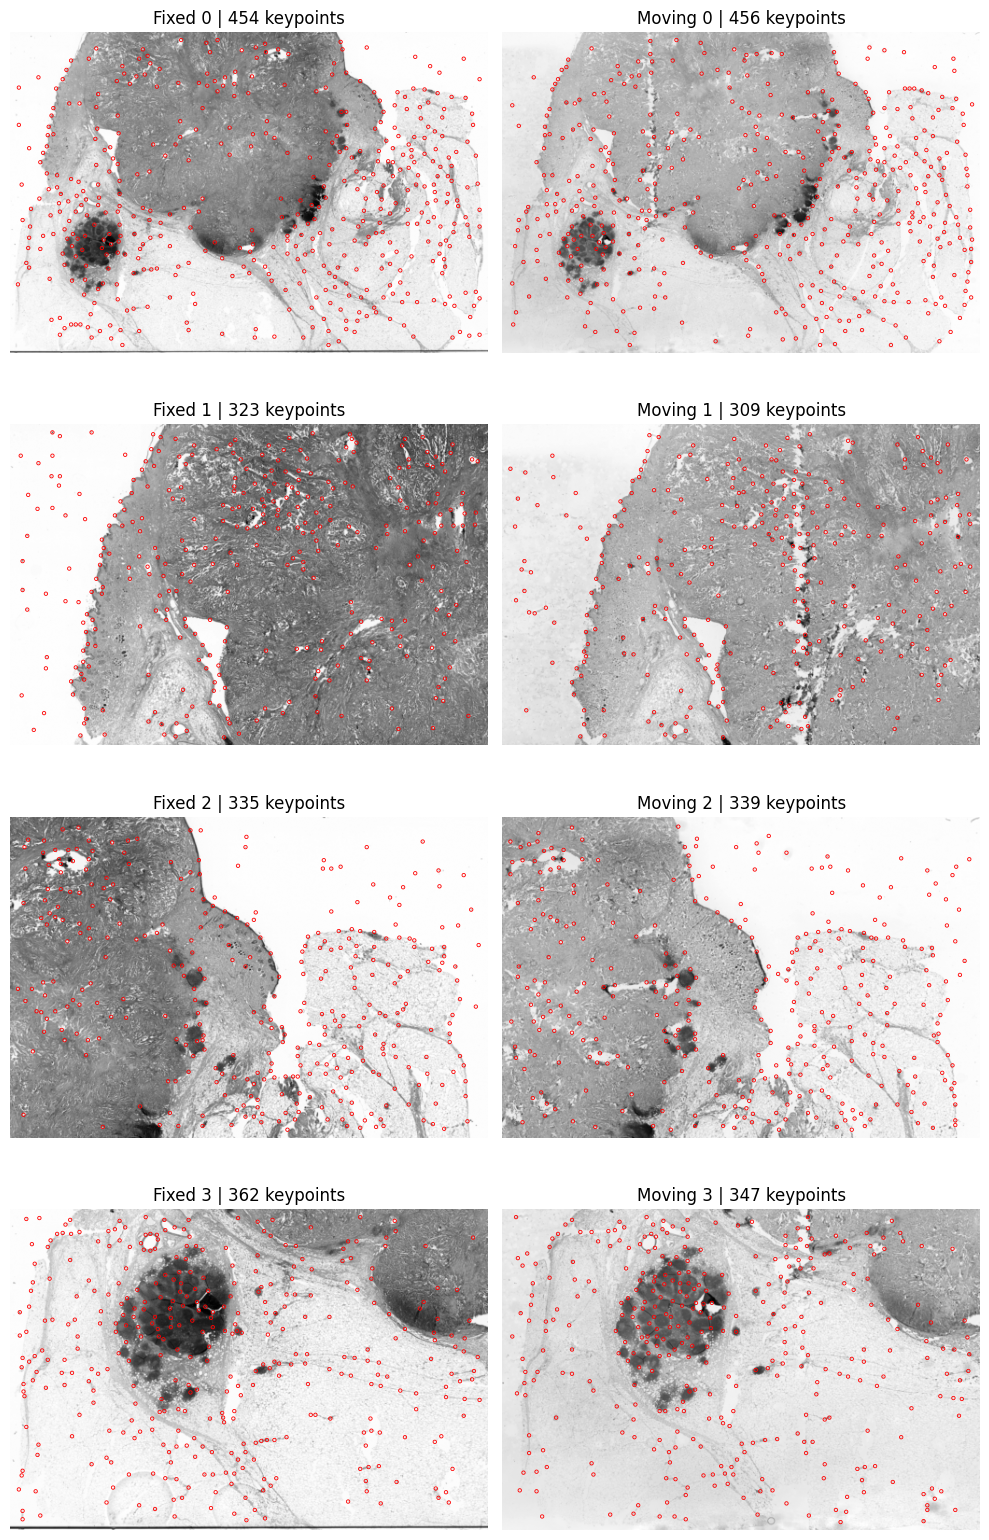

In [13]:
visualize_first_n_superpoint(
    superpoint=superpoint,
    dataloader=loader,
    n_items=4,
)